# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [4]:
df = pd.read_csv("data/SuperStoreOrders.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


# Understanding Data

In [6]:
df.shape

(51290, 21)

In [7]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [9]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


# Data Cleaning

In [11]:
# check Missing values
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [12]:
# Convert date column 
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')

In [13]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)

In [14]:
df['order_date'].isnull().sum()

31223

In [15]:
df[df['order_date'].isnull()].head(10)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
162,EG-2011-4270,NaT,18-01-2011,Standard Class,Roger Demir,Consumer,Aswan,Egypt,Africa,Africa,...,Office Supplies,Storage,"Smead Lockers, Blue",794,4,0.0,134.88,76.60,Medium,2011
163,EG-2011-4270,NaT,18-01-2011,Standard Class,Roger Demir,Consumer,Aswan,Egypt,Africa,Africa,...,Technology,Copiers,"HP Fax Machine, Laser","1,200",4,0.0,479.88,55.62,Medium,2011
164,MX-2011-150567,NaT,17-01-2011,Standard Class,Ben Wallace,Consumer,Jalisco,Mexico,LATAM,North,...,Technology,Machines,"StarTech Inkjet, Wireless",201,1,0.0,100.62,31.78,High,2011
165,IT-2011-5340302,NaT,19-01-2011,Standard Class,Greg Matthias,Consumer,South Holland,Netherlands,EU,Central,...,Office Supplies,Storage,"Smead Lockers, Blue",198,2,0.5,-130.98,14.53,Medium,2011
166,EG-2011-4270,NaT,18-01-2011,Standard Class,Roger Demir,Consumer,Aswan,Egypt,Africa,Africa,...,Office Supplies,Storage,"Fellowes Box, Wire Frame",38,2,0.0,17.22,2.66,Medium,2011
167,US-2011-105760,NaT,17-01-2011,Standard Class,James Lanier,Home Office,Anzoátegui,Venezuela,LATAM,South,...,Office Supplies,Supplies,"Elite Ruler, Steel",26,5,0.4,-8.00,2.20,High,2011
168,IT-2011-5951216,NaT,20-01-2011,Standard Class,Stuart Calhoun,Consumer,Västra Götaland,Sweden,EU,North,...,Office Supplies,Art,"Sanford Pens, Fluorescent",31,5,0.5,-13.65,2.16,Medium,2011
169,IT-2011-5340302,NaT,19-01-2011,Standard Class,Greg Matthias,Consumer,South Holland,Netherlands,EU,Central,...,Office Supplies,Paper,"Green Bar Cards & Envelopes, Multicolor",50,2,0.5,-37.86,1.51,Medium,2011
170,IT-2011-5340302,NaT,19-01-2011,Standard Class,Greg Matthias,Consumer,South Holland,Netherlands,EU,Central,...,Office Supplies,Labels,"Harbour Creations Legal Exhibit Labels, Laser ...",22,4,0.5,-12.30,1.29,Medium,2011
171,IN-2011-38349,NaT,17-01-2011,Standard Class,Cari Sayre,Corporate,South Australia,Australia,APAC,Oceania,...,Office Supplies,Labels,"Harbour Creations Legal Exhibit Labels, Adjust...",16,2,0.1,0.33,0.72,Medium,2011


In [16]:
df['ship_date'] = pd.to_datetime(df['ship_date'], format='mixed', dayfirst=True)

In [17]:
df['order_date'] = df['order_date'].fillna(df['ship_date'])

In [18]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [19]:
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()

In [20]:
df.duplicated(subset=['order_id', 'product_id']).sum()

38

In [21]:
df.duplicated().sum()

0

In [22]:
df[df.duplicated(subset=['order_id','product_id'], keep=False)].sort_values(['order_id','product_id'])

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,month,month_name
42781,AG-2014-4840,2014-08-25,2014-08-25,Standard Class,Cynthia Delaney,Home Office,Oran,Algeria,Africa,Africa,...,"Memorex Mouse, USB",57,2,0.0,10.7400,5.43,High,2014,8,August
42791,AG-2014-4840,2014-08-25,2014-08-25,Standard Class,Cynthia Delaney,Home Office,Oran,Algeria,Africa,Africa,...,"Memorex Mouse, USB",57,2,0.0,10.7400,2.77,High,2014,8,August
13753,CA-2012-103135,2012-07-28,2012-07-28,Standard Class,Shirley Schmidt,Home Office,Kentucky,United States,US,South,...,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",90,6,0.0,41.4276,12.98,High,2012,7,July
13758,CA-2012-103135,2012-07-28,2012-07-28,Standard Class,Shirley Schmidt,Home Office,Kentucky,United States,US,South,...,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",135,9,0.0,62.1414,9.60,High,2012,7,July
27808,CA-2013-129714,2013-09-02,2013-09-04,First Class,Adam Bellavance,Home Office,New York,United States,US,East,...,Xerox 1881,25,2,0.0,11.5432,6.53,Critical,2013,9,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1785,US-2011-150119,2011-04-27,2011-04-27,Standard Class,Laurel Beltran,Home Office,Ohio,United States,US,East,...,Global Leather Highback Executive Chair with P...,281,2,0.3,-12.0588,3.46,Medium,2011,4,April
22459,US-2013-123750,2013-04-22,2013-04-22,Standard Class,Ross Baird,Home Office,North Carolina,United States,US,South,...,Imation Secure+ Hardware Encrypted USB 2.0 Fla...,409,7,0.2,76.6395,67.33,Low,2013,4,April
22460,US-2013-123750,2013-04-22,2013-04-22,Standard Class,Ross Baird,Home Office,North Carolina,United States,US,South,...,Imation Secure+ Hardware Encrypted USB 2.0 Fla...,292,5,0.2,54.7425,52.10,Low,2013,4,April
35085,UZ-2014-7970,2014-02-21,2014-02-21,Second Class,Valerie Dominguez,Consumer,Andijan,Uzbekistan,EMEA,EMEA,...,"Ibico 3-Hole Punch, Durable",64,2,0.0,23.6400,6.88,Medium,2014,2,February


# Feature Engineering

In [24]:
df[['order_date','ship_date']].dtypes

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object

In [25]:
# Extract year 
df['year'] = df['order_date'].dt.year

In [26]:
# Extract Month 
df['month'] = df['order_date'].dt.month

In [27]:
# Extract Month Name
df['month_name'] = df['order_date'].dt.month_name()

In [28]:
df['sales'].dtype

dtype('O')

In [29]:
df['sales'] = df['sales'].astype(str) 
df['sales'] = df['sales'].str.replace(',', '') 
df['sales'] = df['sales'].str.strip() 

In [30]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [31]:
df['sales'] = df['sales'].astype(float)

In [32]:
df['sales'].dtype

dtype('float64')

In [33]:
# Create Profit Margin
df['profit_margin'] = (df['profit'] / df['sales']) * 100

In [34]:
df[['sales','profit','profit_margin']].head()

,sales,profit,profit_margin
0,408.0,106.140,26.014706
1,120.0,36.036,30.030000
2,66.0,29.640,44.909091
3,45.0,-26.055,-57.900000
4,114.0,37.770,33.131579


# Exploratory Data Analysis

## Business Overview

In [37]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 12642905.0
Total Profit: 1469034.8212799998
Total Orders: 25035


## Calculate Key Ratios

In [39]:
profit_margin_overall = (total_profit / total_sales) * 100
avg_order_value = total_sales / total_orders

print("Overall Profit Margin (%):", profit_margin_overall)
print("Average Order Value:", avg_order_value)

Overall Profit Margin (%): 11.61944047890892
Average Order Value: 505.0091871380068


## Category Analysis

In [41]:
df.groupby('category')['sales'].sum().sort_values(ascending=False)

category
Technology         4744691.0
Furniture          4110884.0
Office Supplies    3787330.0
Name: sales, dtype: float64

## Category Profit Analysis

In [43]:
category_profit = df.groupby('category')['profit'].sum().sort_values()
category_profit

category
Furniture          286782.25380
Office Supplies    518473.83430
Technology         663778.73318
Name: profit, dtype: float64

##  Visualization

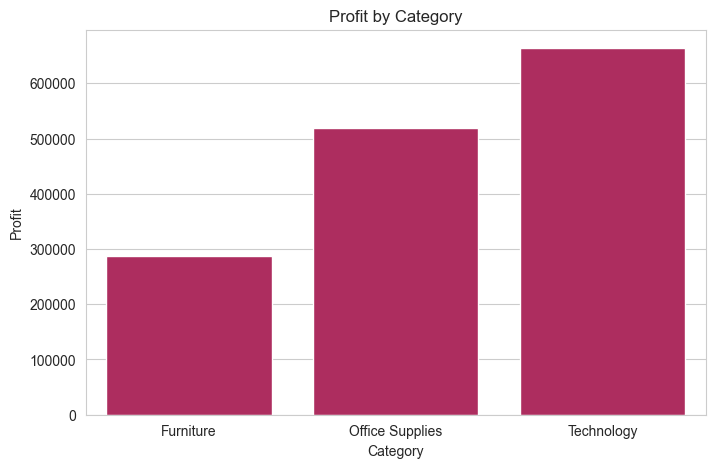

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

category_profit = df.groupby('category')['profit'].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=category_profit,
    x='category',
    y='profit',
    color='#C2185B'   
)

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')

plt.show()

#
Technology is the most profitable category, contributing the highest share of total profit. Office Supplies shows stable performance, while Furniture lags behind, suggesting a need for cost optimization or pricing strategy improvements.

In [47]:
category_profit = df.groupby('category')['profit'].sum()

(category_profit / category_profit.sum()) * 100

category
Furniture          19.521815
Office Supplies    35.293502
Technology         45.184683
Name: profit, dtype: float64

#
Technology contributes approximately  45.18 % of total profit, dominating overall profitability.

## Sub-Category Analysis

In [50]:
subcat_analysis = df.groupby('sub_category').agg({
    'sales':'sum',
    'profit':'sum'
}).sort_values(by='sales', ascending=False)

subcat_analysis.head(10)


,sales,profit
sub_category,,
Phones,1706874.0,216717.00580
Copiers,1509439.0,258567.54818
Chairs,1501682.0,141973.79750
Bookcases,1466559.0,161924.41950
Storage,1127124.0,108461.48980
Appliances,1011081.0,141680.58940
Machines,779071.0,58867.87300
Tables,757034.0,-64083.38870
Accessories,749307.0,129626.30620


In [51]:
subcat_sorted = subcat_analysis.sort_values(by='sales', ascending=False).head(10)

##  Visualization

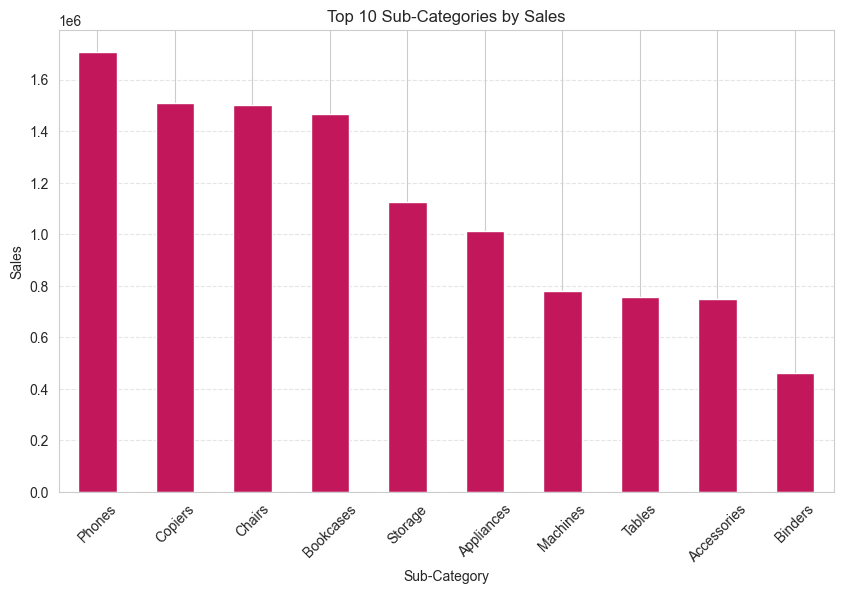

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

subcat_sorted['sales'].plot(
    kind='bar',
    color='#C2185B'
)

plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#
Phones and Copiers are the top-performing sub-categories in terms of sales, contributing significantly to overall revenue. However, Tables show negative profit despite considerable sales, indicating a potential issue with pricing or high discounting.

<Axes: xlabel='sub_category'>

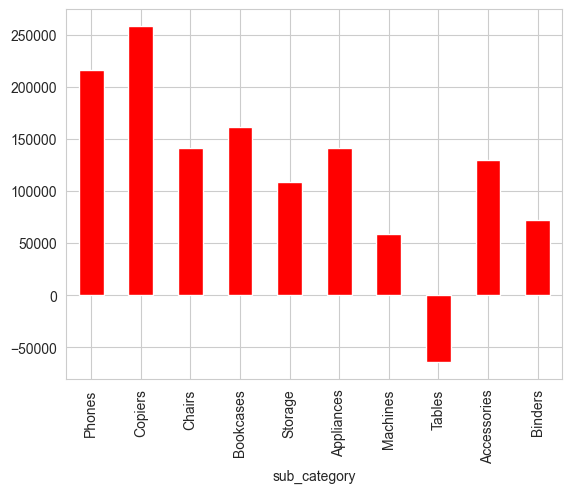

In [55]:
subcat_sorted['profit'].plot(kind='bar', color='red')

#
The Tables sub-category is generating negative profit despite having significant sales, indicating potential issues such as high discounts, pricing inefficiencies, or high operational costs.

Sub-categories like Copiers and Phones are highly profitable and contribute significantly to overall profit, making them key drivers of business success.

Machines generate relatively high sales but comparatively low profit, suggesting lower profit margins and possible inefficiencies.

Some sub-categories achieve a balance between sales and profitability, while others either underperform or incur losses, indicating the need for category-specific strategies.

## Region-wise Sales & Profit


In [58]:
region_analysis = df.groupby('region').agg({
    'sales': 'sum',
    'profit': 'sum'
}).sort_values(by='sales', ascending=False)

region_analysis

,sales,profit
region,,
Central,2822399.0,311403.98164
South,1600960.0,140355.76618
North,1248192.0,194597.95252
Oceania,1100207.0,121666.64200
Southeast Asia,884438.0,17852.32900
North Asia,848349.0,165578.42100
EMEA,806184.0,43897.97100
Africa,783776.0,88871.63100
Central Asia,752839.0,132480.18700


In [59]:
region_analysis['profit_margin'] = (region_analysis['profit'] / region_analysis['sales']) * 100
region_analysis.sort_values(by='profit_margin', ascending=False)

,sales,profit,profit_margin
region,,,
Canada,66932.0,17817.39000,26.620137
North Asia,848349.0,165578.42100,19.517725
Central Asia,752839.0,132480.18700,17.597413
North,1248192.0,194597.95252,15.590386
West,725514.0,108418.44890,14.943674
East,678834.0,91522.78000,13.482351
Africa,783776.0,88871.63100,11.338907
Oceania,1100207.0,121666.64200,11.058523
Central,2822399.0,311403.98164,11.033308


## Visualization (Sales by Region)

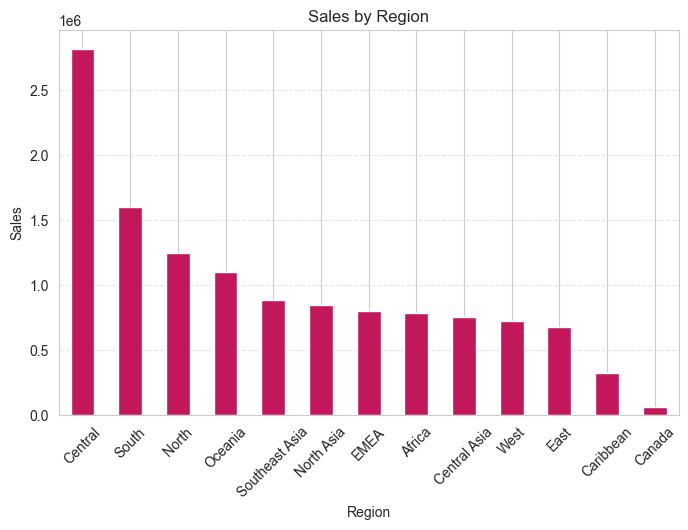

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

region_analysis['sales'].plot(
    kind='bar',
    color='#C2185B'
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Visualization (Profit by Region)

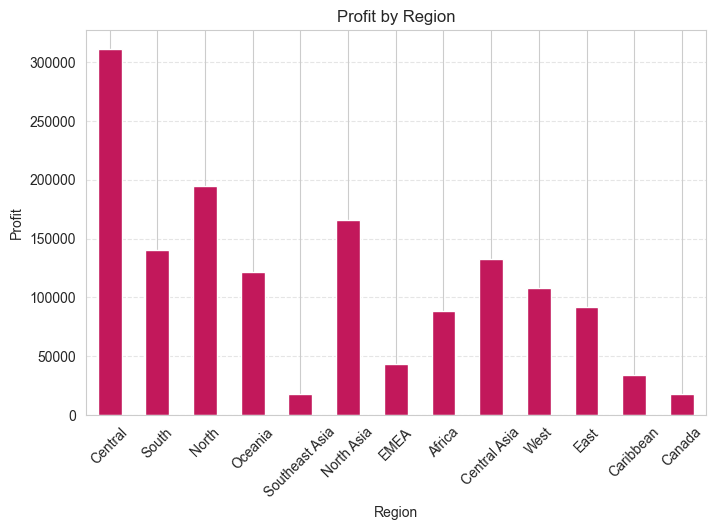

In [63]:
plt.figure(figsize=(8,5))

region_analysis['profit'].plot(
    kind='bar',
    color='#C2185B'
)

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#
The Central region generates the highest sales and profit, making it the most significant contributor to overall business performance.

Regions like North Asia and Central Asia show strong profitability relative to their sales, indicating efficient operations and better profit margins.

Southeast Asia records substantial sales but extremely low profit, highlighting a major inefficiency likely caused by high discounts or operational costs.

Canada and Caribbean contribute minimally to total sales and profit, suggesting limited market presence or lower demand.

Despite strong sales in certain regions, profitability varies significantly, indicating that high revenue does not always translate into high profit, and region-specific strategies are required.

Some regions achieve higher profit margins with lower sales, indicating more efficient pricing and cost control strategies.

In [65]:
region_analysis.sort_values(by='profit').head()

,sales,profit,profit_margin
region,,,
Canada,66932.0,17817.39000,26.620137
Southeast Asia,884438.0,17852.32900,2.018494
Caribbean,324281.0,34571.32104,10.660915
EMEA,806184.0,43897.97100,5.445155
Africa,783776.0,88871.63100,11.338907


## Monthly Sales Calculation

In [67]:
monthly_sales = df.groupby('month')['sales'].sum().sort_index()
monthly_sales

month
1      773708.0
2      559129.0
3      760958.0
4      699036.0
5      835409.0
6     1253733.0
7      832816.0
8     1211168.0
9     1437205.0
10    1207521.0
11    1467627.0
12    1604595.0
Name: sales, dtype: float64

In [68]:
id="ymn1fj"
import calendar

monthly_sales.index = [calendar.month_name[i] for i in monthly_sales.index]
monthly_sales

January       773708.0
February      559129.0
March         760958.0
April         699036.0
May           835409.0
June         1253733.0
July          832816.0
August       1211168.0
September    1437205.0
October      1207521.0
November     1467627.0
December     1604595.0
Name: sales, dtype: float64

## Visualization

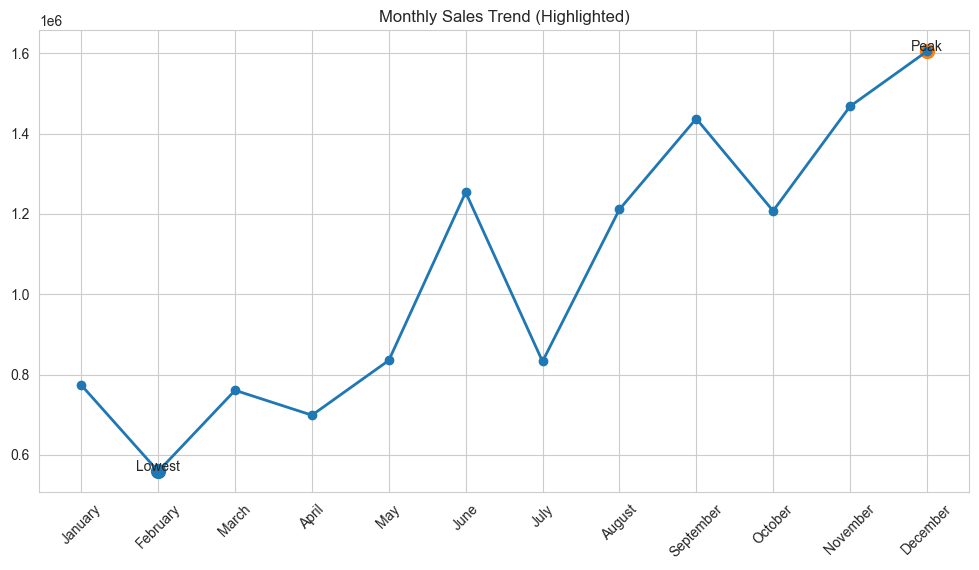

In [70]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales, marker='o', linewidth=2)

# Highlight max & min
max_val = monthly_sales.max()
min_val = monthly_sales.min()

for i, value in enumerate(monthly_sales):
    if value == max_val:
        plt.scatter(i, value, s=100)
        plt.text(i, value, "Peak", ha='center')
    elif value == min_val:
        plt.scatter(i, value, s=100)
        plt.text(i, value, "Lowest", ha='center')

plt.title('Monthly Sales Trend (Highlighted)')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [71]:
# Monthly Profit Trend
monthly_profit = df.groupby('month')['profit'].sum().sort_index()
id="ymn1fj"
import calendar

monthly_profit.index = [calendar.month_name[i] for i in monthly_profit.index]
monthly_profit

January       83351.77592
February      76020.42746
March         91806.50422
April         71870.22078
May           99415.92656
June         139823.70654
July          92806.05472
August       142172.63354
September    172399.65300
October      158235.11434
November     173805.42420
December     167327.38000
Name: profit, dtype: float64

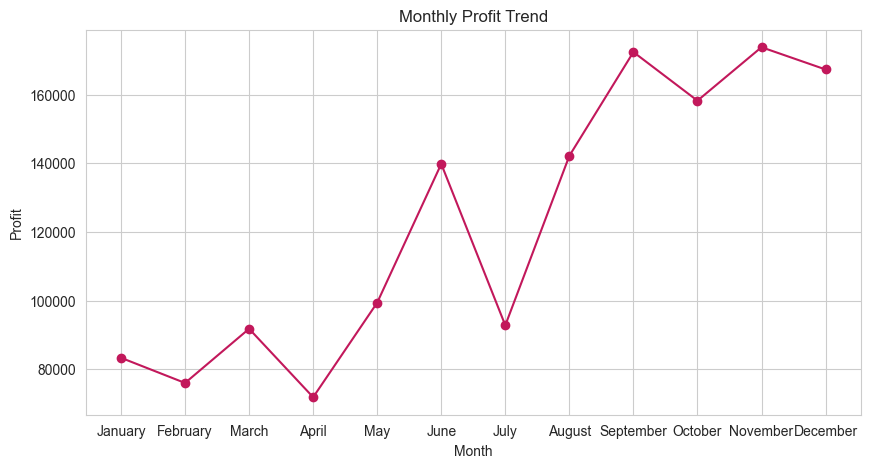

In [72]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_profit,
    marker='o',
    color='#C2185B'
)

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')

plt.grid(True)
plt.show()

## 
Both sales and profit show a strong upward trend towards the end of the year, with peak performance observed in the months of September, November, and December, indicating high seasonal demand during this period.

The beginning of the year, particularly February and April, shows comparatively lower sales and profit, suggesting a seasonal slowdown in business activity.

Sales and profit begin to rise steadily from June onwards, marking the transition from low-demand to high-demand periods.

Profit trends closely follow sales trends, indicating that increased sales generally translate into higher profitability, although efficiency may still vary across months.

The period from September to December represents the most profitable phase of the business, highlighting an opportunity for maximizing revenue through targeted marketing and inventory planning.

## Discount vs Profit Analysis 

In [75]:
# Clean the Data
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

## Scatter Plot

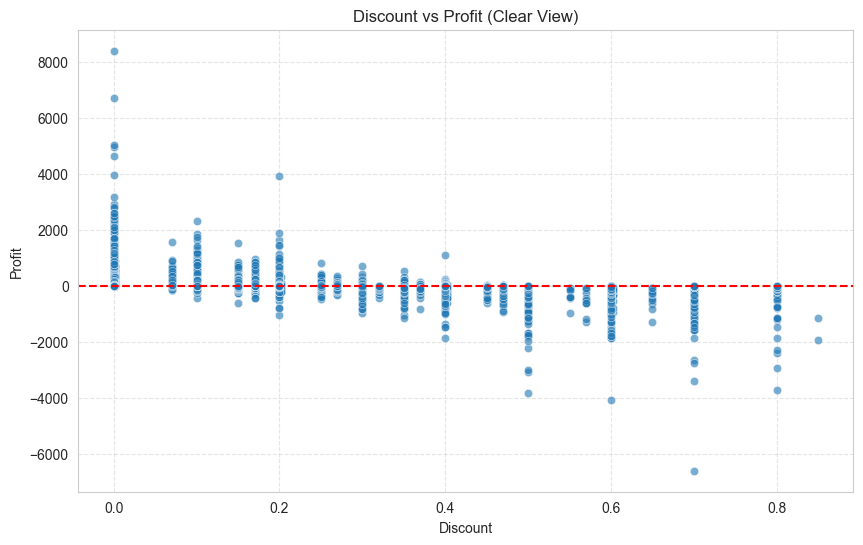

In [77]:
# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='discount',
    y='profit',
    alpha=0.6
)

plt.axhline(0, color='red', linestyle='--')  # profit = 0 line

plt.title('Discount vs Profit (Clear View)')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

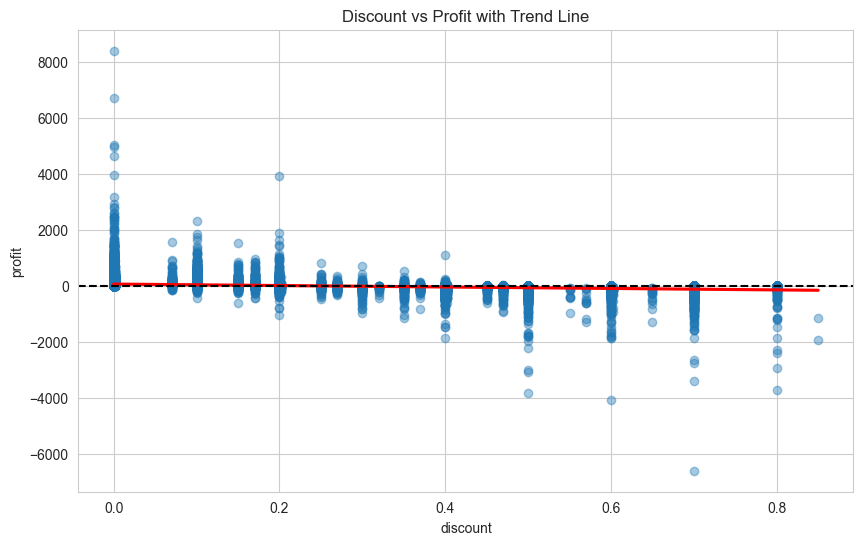

In [78]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='discount',
    y='profit',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.axhline(0, color='black', linestyle='--')

plt.title('Discount vs Profit with Trend Line')
plt.show()

In [136]:
# Average Profit per Discount
df.groupby('discount')['profit'].mean().sort_index()

discount
0.000      61.039514
0.002     125.762649
0.070     140.990022
0.100      64.071216
0.150      50.602409
0.170      38.317107
0.200      23.552594
0.202     -14.518847
0.250       4.043371
0.270      -4.317213
0.300     -57.899557
0.320     -88.560656
0.350    -116.144693
0.370     -78.462191
0.400     -45.246603
0.402    -109.908138
0.450     -41.610973
0.470     -42.982420
0.500     -97.140158
0.550    -315.067200
0.570    -526.129000
0.600     -81.732147
0.602    -213.279085
0.650    -365.997971
0.700    -104.339576
0.800    -122.203244
0.850   -1534.329000
Name: profit, dtype: float64

In [140]:
df.groupby('discount_bin', observed=False)['profit'].mean()

discount_bin
(-0.00085, 0.17]     62.456922
(0.17, 0.34]         18.185252
(0.34, 0.51]        -61.433573
(0.51, 0.68]        -89.239019
(0.68, 0.85]       -108.381828
Name: profit, dtype: float64

In [141]:
df['discount_bin'] = pd.cut(df['discount'], bins=5)

df.groupby('discount_bin')['profit'].mean()

C:\Users\DELL\AppData\Local\Temp\ipykernel_13432\2349249972.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('discount_bin')['profit'].mean()


discount_bin
(-0.00085, 0.17]     62.456922
(0.17, 0.34]         18.185252
(0.34, 0.51]        -61.433573
(0.51, 0.68]        -89.239019
(0.68, 0.85]       -108.381828
Name: profit, dtype: float64

#
Profit decreases significantly as discount increases, showing a strong negative relationship between discount and profitability.

Discounts above approximately 30% lead to negative average profit, indicating a critical threshold beyond which transactions become unprofitable.

High discount levels (above 50%) result in substantial losses, making aggressive discounting a key driver of negative profitability.

Low discount levels maintain positive profitability, suggesting that controlled discount strategies can balance revenue and profit effectively.

The analysis reveals a clear threshold effect where discounts beyond 30% lead to consistent losses, highlighting the need for strict discount control to maintain profitability.

In [145]:
df.to_csv("cleaned_data.csv", index=False)